In [1]:
import os, sys,random, glob, math
from typing import Dict, Tuple
import cv2
import numpy as np
import pandas as pd
from scipy import ndimage as ndi
from skimage.morphology import disk, dilation
import pytesseract
import pyarrow.parquet as pq
import pyarrow as pa
import warnings
from tqdm.auto import tqdm
warnings.filterwarnings("ignore", category=RuntimeWarning)

import matplotlib.pyplot as plt

In [2]:
from PIL import Image
img = Image.open("/kaggle/input/physionet-ecg-image-digitization/train/1006427285/1006427285-0001.png")

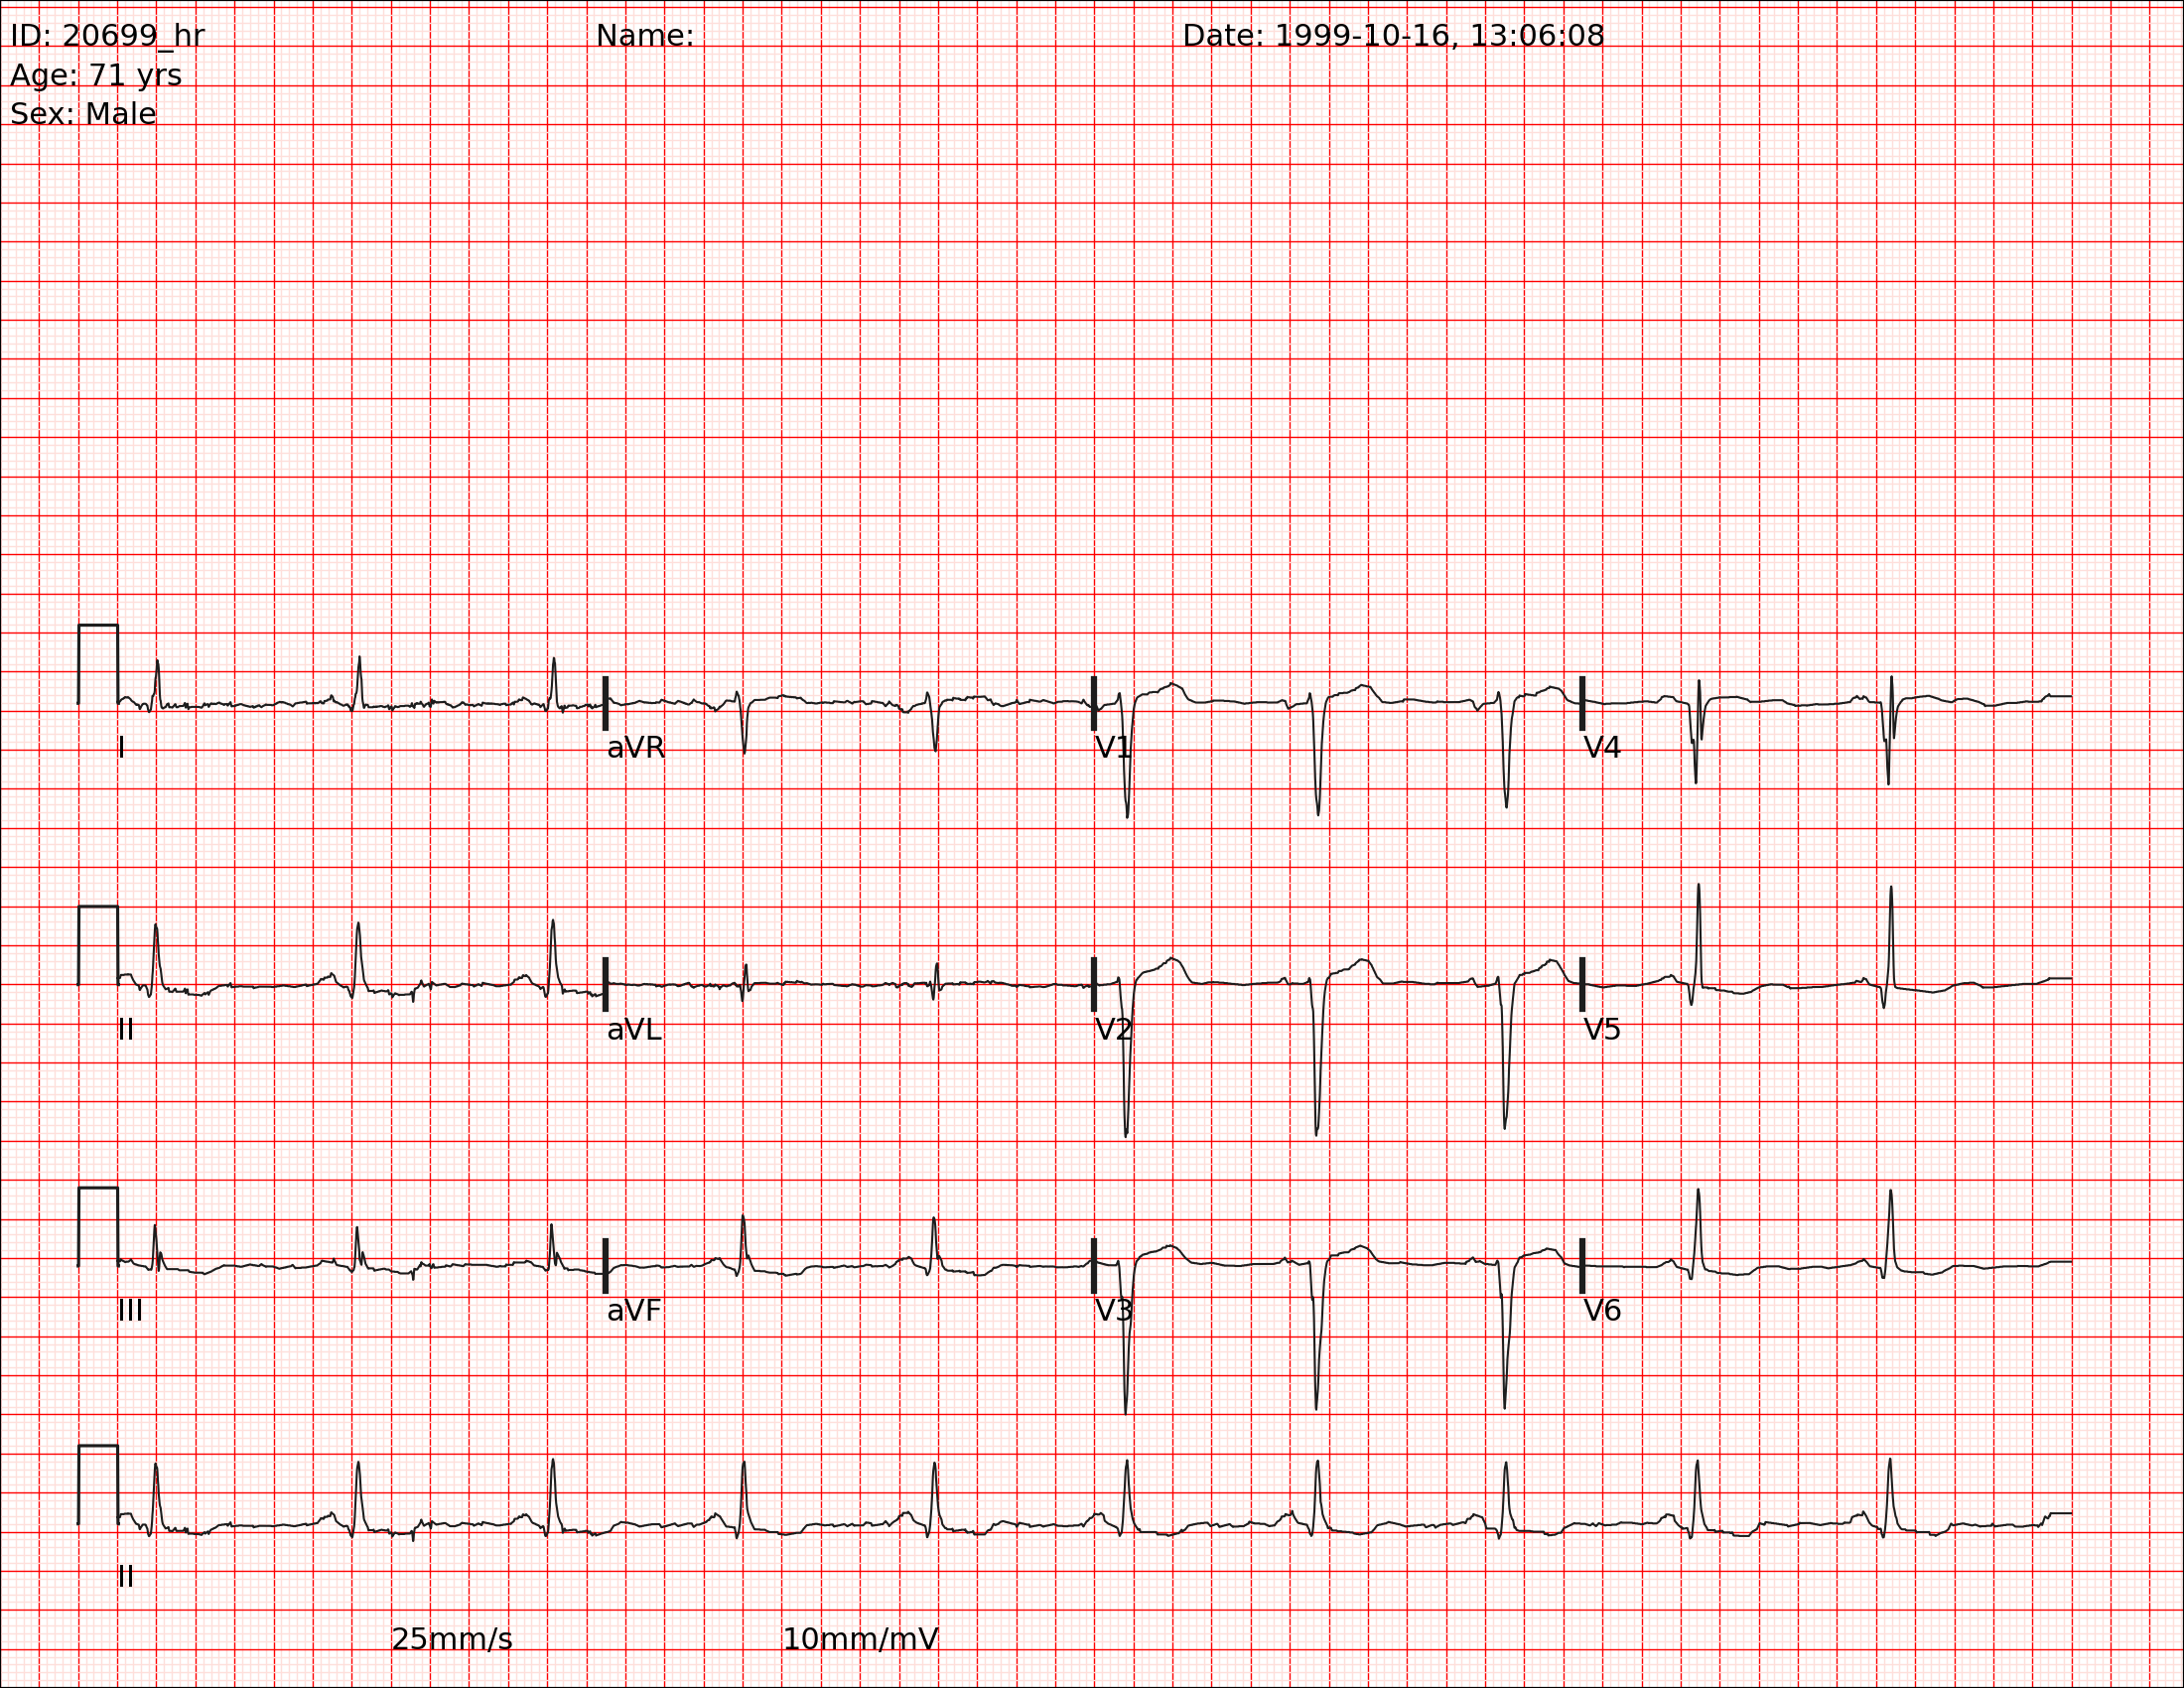

In [3]:
img

In [4]:
print("Image loaded successfully!")
print(f"Image format: {img.format}")
print(f"Image size: {img.size}")

Image loaded successfully!
Image format: PNG
Image size: (2200, 1700)


In [5]:
img_cv2 = cv2.imread("/kaggle/input/physionet-ecg-image-digitization/train/1006427285/1006427285-0001.png")

# extract height and width of image
h, w = img_cv2.shape[:2]

In [6]:
print(h,w)

1700 2200


In [7]:
print(img_cv2.shape)

(1700, 2200, 3)


In [8]:
gray = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2GRAY)
gray_blur = cv2.GaussianBlur(gray, (3,3), 0)

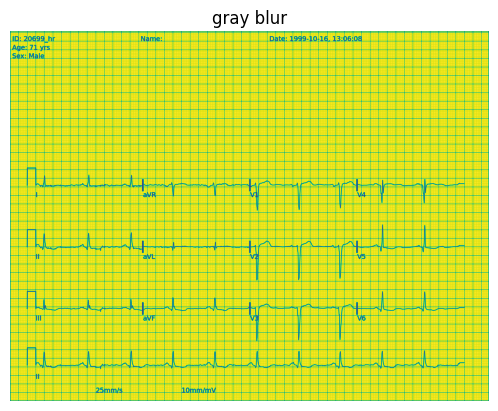

In [9]:
plt.imshow(gray)  
plt.title('gray blur')
plt.axis('off')  
plt.show()

In [10]:
gray = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2GRAY)
row_means = gray.mean(axis=1)
# find topmost row that's not black
non_black_rows = np.where(row_means > 1)[0]

if non_black_rows.size > 0:
        top = non_black_rows[0]
        img_cv2 = img_cv2[top:, :, :]
        gray = gray[top:, :]

In [11]:
# remove gridlines: use red channel strategy from paper
red = img_cv2[:, :, 2].astype(np.float32) / 255.0

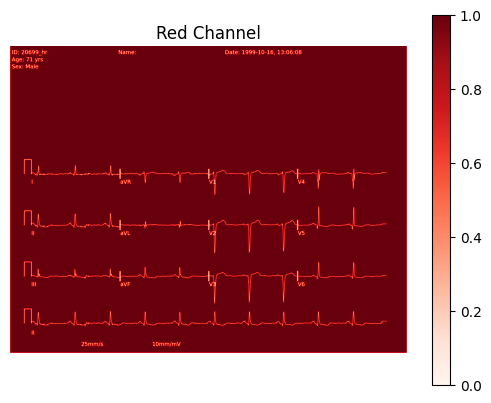

In [12]:
# 'red' is a 2D array with values normalized between 0 and 1
plt.imshow(red, cmap='Reds')  # Use 'Reds' colormap to show the red intensity
plt.colorbar()  # Optional: shows intensity color scale
plt.title('Red Channel')
plt.axis('off')  # Hide axis ticks
plt.show()

In [13]:
# create mask where red-channel <= threshold (likely ECG ink or text)
red_threshold=0.94
mask = (red <= red_threshold).astype(np.uint8) * 255

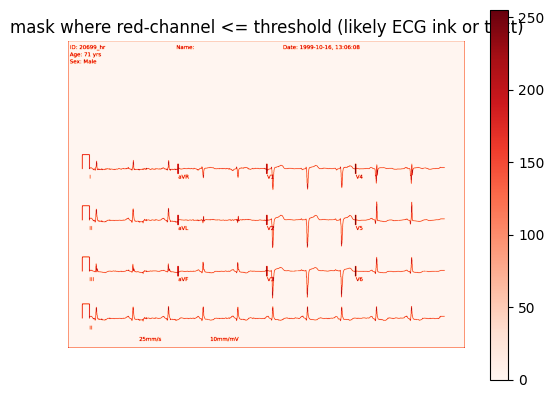

In [14]:
# mask where red-channel <= threshold (likely ECG ink or text)
plt.imshow(mask, cmap='Reds')  # Use 'Reds' colormap to show the red intensity
plt.colorbar()  # Optional: shows intensity color scale
plt.title('mask where red-channel <= threshold (likely ECG ink or text)')
plt.axis('off')  # Hide axis ticks
plt.show()

In [15]:
# Combine with grayscale thresholding to remove background
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
binary = cv2.bitwise_and(binary, mask)

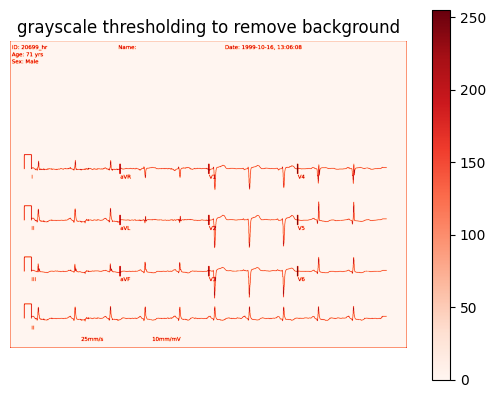

In [16]:
# grayscale thresholding to remove background
plt.imshow(mask, cmap='Reds')  # Use 'Reds' colormap to show the red intensity
plt.colorbar()  # Optional: shows intensity color scale
plt.title('grayscale thresholding to remove background')
plt.axis('off')  # Hide axis ticks
plt.show()

In [17]:
# morphological opening to remove sparse noise
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)


In [18]:
print(binary)

[[  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 ...
 [  0   0   0 ...   0   0   0]
 [255   0   0 ...   0   0 255]
 [255 255   0 ...   0 255 255]]


In [19]:
# Config 
# -----------------------
TRAIN_DIR = "/kaggle/input/physionet-ecg-image-digitization/train"   # root train folder (contains id subfolders)
TEST_DIR = "/kaggle/input/physionet-ecg-image-digitization/test"     # test images folder (test/{id}.png)
TRAIN_CSV = "/kaggle/input/physionet-ecg-image-digitization/train.csv"
TEST_CSV = "/kaggle/input/physionet-ecg-image-digitization/test.csv"
OUT_DIR = "/kaggle/working/"
# os.makedirs(OUT_DIR, exist_ok=True)

LEADS = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]


In [20]:
# Default durations
DURATION_LEAD = { "II": 10.0 }  # lead II is 10s
for lead in LEADS:
    if lead != "II":
        DURATION_LEAD[lead] = 2.5

# physical conversion constant used by many printed ECGs: 0.1 mV per 40 ms -> 0.0025 mV/ms

MV_PER_MS = 0.0025


In [21]:
# -----------------------
# Helpers: image preprocessing
# -----------------------
def load_image(img_path, max_dim=2000):
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(img_path)
    H,W = img.shape[:2]
    if max(H,W) > max_dim:
        scale = max_dim / max(H,W)
        img = cv2.resize(img, (int(W*scale), int(H*scale)), interpolation=cv2.INTER_AREA)
    return img


In [22]:
def preprocess_for_ink(img, red_threshold=0.94):
    """
    Return grayscale and binary mask with ink/high-contrast parts preserved.
    Mask aims to remove red gridlines where possible (for color images).
    """
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_blur = cv2.GaussianBlur(gray, (3,3), 0)
    # mask out red-ish (keep non-red) to reduce gridline interference on color scans
    red = img[:,:,2].astype(np.float32) / 255.0
    mask_red = (red <= red_threshold).astype(np.uint8) * 255
    _, binotsu = cv2.threshold(gray_blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    binary = cv2.bitwise_and(binotsu, mask_red)
    # remove very small specks but keep thin ink traces
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
    return gray, binary


In [23]:
# -----------------------
# OCR-based lead detection (best-effort) + fallback
# -----------------------
def detect_lead_boxes_tesseract(img_color):
    """Return dict lead->(x,y,w,h) using pytesseract; best-effort. If empty, fallback to grid."""
    try:
        gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
        gray = cv2.equalizeHist(gray)
        data = pytesseract.image_to_data(gray, config="--psm 6", output_type=pytesseract.Output.DICT)
    except Exception as e:
        warnings.warn(f"OCR failed: {e}")
        return {}
    boxes = {}
    n = len(data['text'])
    for i in range(n):
        txt = data['text'][i].strip()
        if not txt:
            continue
        t = txt.replace(".", "").upper()
        
        # allowing common label shapes (like, AVR, AVL, AVF)
        if t in [l.upper() for l in LEADS]:
            boxes[t] = (data['left'][i], data['top'][i], data['width'][i], data['height'][i])
    return boxes


In [24]:
def fallback_grid_boxes(img_shape):
    """Default 3x4 grid boxes. Many ECG prints follow a 3 rows x 4 columns layout."""
    H,W = img_shape[:2]
    rows, cols = 3, 4
    box_h = H // rows
    box_w = W // cols
    boxes = {}
    order = LEADS[:]  # assume left-to-right top-to-bottom roughly matches order
    idx = 0
    for r in range(rows):
        for c in range(cols):
            if idx >= len(order):
                break
            x = c*box_w
            y = r*box_h
            boxes[order[idx]] = (x,y,box_w,box_h)
            idx += 1
    return boxes


In [25]:
# -----------------------
# Lead cropping
# -----------------------
def crop_leads_from_boxes(img_color, binary, boxes, expand_x=0.1, expand_y=0.3):
    """Return dict lead: (crop_color, crop_binary). Boxes are local label boxes; expand to include trace."""
    H, W = binary.shape[:2]
    vertical_expansion = int(0.6 * next(iter(boxes.values()))[3]) if boxes else 0  # approximate extra vertical expansion

    crops = {}
    for lead, (x, y, w, h) in boxes.items():
        mx = int(w * expand_x)
        my = int(h * expand_y)

        x1 = max(0, x - mx)
        x2 = min(W, x + w + mx)

        y1 = max(0, y - my)
        y2 = min(H, y + h + my + vertical_expansion)

        crop_c = img_color[y1:y2, x1:x2].copy()
        crop_b = binary[y1:y2, x1:x2].copy()
        crops[lead] = (crop_c, crop_b)

    return crops


In [26]:
# -----------------------
# Extract 1D signal from crop
# -----------------------
def extract_1d_from_crop_binary(crop_bin, method="median", fill_gaps=True):
    """Return vertical pixel positions (y) per column (width). None on failure."""
    if crop_bin is None or crop_bin.size == 0:
        return None
    
    bw = (crop_bin > 0).astype(np.uint8)
    h, w = bw.shape
    
    # Early exit if too little ink
    if bw.sum() < max(10, int(0.001 * h * w)):
        return None
    
    xs = np.arange(w)
    sig = np.full(w, np.nan, dtype=float)
    
    # Vectorized computation across all columns
    col_sums = bw.sum(axis=0)
    non_empty_cols = col_sums > 0
    
    for x in xs:
        ys = np.where(bw[:, x] > 0)[0]
        if ys.size == 0:
            continue
        sig[x] = np.median(ys)
    
    else:
        # Vectorized center of mass (faster)
        idx = np.arange(h)
        sig[non_empty_cols] = (bw[:, non_empty_cols] * idx[:, None]).sum(axis=0) / col_sums[non_empty_cols]
    
    # Interpolate gaps (vectorized)
    if fill_gaps and np.isnan(sig).any():
        good = ~np.isnan(sig)
        if good.sum() > 0:
            sig = np.interp(xs, xs[good], sig[good])
    
    return sig if np.any(~np.isnan(sig)) else None



In [27]:
# -----------------------
# Rhythms & calibration helpers
# -----------------------
def select_rhythm_strip_name(crops: Dict[str, Tuple[np.ndarray, np.ndarray]]) -> str:
    """Heuristic: rhythm strip often the crop with largest width; return lead name."""
    valid_crops = [(lead, binary.shape[1]) for lead, (_, binary) in crops.items() 
                   if binary is not None]
    return max(valid_crops, key=lambda x: x[1])[0] if valid_crops else None


In [28]:
# compute time_per_pixel for a record if we know rhythm pixel length and total duration (seconds)
def compute_time_per_pixel_from_rhythm(rhythm_pixels: int, duration_s: float) -> float | None:
    return duration_s / rhythm_pixels if rhythm_pixels > 0 else None



In [29]:
# compute a voltage-per-pixel scaler for a train record by linear fit between ground-truth samples and pixel-derived signal
def fit_voltage_scale_between_pixel_signal_and_true(pixel_signal, true_signal_samples):
    """
    Fit linear mapping true = a*(median - pixel) + b for pixel and true signal arrays.
    Returns scale factor a (mV/pixel) and intercept b.
    """
    if pixel_signal is None or pixel_signal.size < 5:
        return None, None

    n_true = true_signal_samples.size

    # Resample pixel_signal to same length as true_signal_samples
    xp = np.arange(pixel_signal.size)
    pix_resampled = np.interp(np.linspace(0, pixel_signal.size - 1, n_true), xp, pixel_signal)

    # Center pixel positions relative to median and invert sign for positive deflection
    pix_centered = np.median(pix_resampled) - pix_resampled

    # Prepare design matrix for least squares
    A = np.column_stack((pix_centered, np.ones(n_true)))

    try:
        a, b = np.linalg.lstsq(A, true_signal_samples, rcond=None)[0]
        return float(a), float(b)
    except np.linalg.LinAlgError:
        return None, None



In [30]:
# -----------------------
# Training calibration learner
# -----------------------
def learn_calibration_from_train(train_dir, train_csv_path, max_records=None, debug=False):
    """
    Estimate time_per_pixel and global voltage-per-pixel calibration from training records.
    
    Returns:
      record_time_per_pixel: dict rec_id -> time_per_pixel (s)
      global_voltage_per_pixel_mV: scalar (robust median across fitted records)
    """
    meta = pd.read_csv(train_csv_path)
    record_time = {}
    voltage_per_pixel_list = []
    processed = 0

    # Preferred suffix order for image files to check (avoid recreating list each iteration)
    preferred_suffixes = ['-0001.png', '-0003.png', '-0004.png', '-0005.png',
                          '-0006.png', '-0009.png', '-0010.png', '-0011.png', '-0012.png']

    for rec_id in meta['id'].astype(str):
        if max_records and processed >= max_records:
            break

        try:
            fs = float(meta.loc[meta['id'] == int(rec_id), 'fs'].values[0])
            sig_len = int(meta.loc[meta['id'] == int(rec_id), 'sig_len'].values[0])
            duration_s = sig_len / fs
        except Exception as e:
            if debug:
                print(f"[train calibrate] {rec_id} metadata read failed: {e}")
            processed += 1
            continue

        folder = os.path.join(train_dir, rec_id)
        if not os.path.isdir(folder):
            processed += 1
            continue

        # Find suitable image file
        candidates = [os.path.join(folder, f"{rec_id}{s}") for s in preferred_suffixes if os.path.exists(os.path.join(folder, f"{rec_id}{s}"))]
        if not candidates:
            globp = glob.glob(os.path.join(folder, "*.png"))
            if not globp:
                processed += 1
                continue
            candidates = [globp[0]]
        img_path = candidates[0]

        # Load image and preprocess
        img = load_image(img_path)
        gray, binary = preprocess_for_ink(img)
        boxes = detect_lead_boxes_tesseract(img) or fallback_grid_boxes(img.shape)
        crops = crop_leads_from_boxes(img, binary, boxes)
        rhythm_name = select_rhythm_strip_name(crops)
        if rhythm_name is None:
            processed += 1
            continue

        rhythm_crop = crops[rhythm_name][1]  # binary
        rhythm_w = rhythm_crop.shape[1]
        tpp = compute_time_per_pixel_from_rhythm(rhythm_w, duration_s)
        if tpp is None:
            processed += 1
            continue
        record_time[rec_id] = tpp

        # Load ground truth CSV for voltage fitting
        gt_path = os.path.join(folder, f"{rec_id}.csv")
        if not os.path.exists(gt_path):
            alt = os.path.join(folder, f"{rec_id}_signals.csv")
            gt_path = alt if os.path.exists(alt) else None
        if not gt_path:
            processed += 1
            continue

        gt_df = pd.read_csv(gt_path)
        chosen_lead = 'II' if 'II' in gt_df.columns else gt_df.columns[0]
        true_signal = gt_df[chosen_lead].values

        if chosen_lead in crops:
            pix = extract_1d_from_crop_binary(crops[chosen_lead][1])
        else:
            widest = select_rhythm_strip_name(crops)
            pix = extract_1d_from_crop_binary(crops[widest][1]) if widest else None

        if pix is None:
            processed += 1
            continue

        a, _ = fit_voltage_scale_between_pixel_signal_and_true(pix, true_signal)
        if a is not None:
            voltage_per_pixel_list.append(a)

        processed += 1

    if not voltage_per_pixel_list:
        warnings.warn("No voltage-per-pixel fits found in training; using fallback 0.005 mV/pixel")
        global_voltage = 0.005
    else:
        global_voltage = float(np.median(voltage_per_pixel_list))
    return record_time, global_voltage


In [31]:
# -----------------------
# Process a single image (train or test)
# -----------------------
def process_image_extract_signals(img_path, time_per_pixel=None, global_voltage_per_pixel=None, do_ocr=True, debug=False):
    """
    Returns dict lead -> 1D numpy array of mV values sampled at pixel columns (time axis = pixel columns * time_per_pixel)
    If time_per_pixel or global_voltage_per_pixel is None, returns pixel-coordinate signals (not scaled).
    """
    img = load_image(img_path)
    gray, binary = preprocess_for_ink(img)
    boxes = {}
    if do_ocr:
        try:
            boxes = detect_lead_boxes_tesseract(img)
        except Exception:
            boxes = {}
    if not boxes:
        boxes = fallback_grid_boxes(img.shape)
    crops = crop_leads_from_boxes(img, binary, boxes)
    # extract pixel signals
    pixel_signals = {}
    for lead,(ccolor, cbin) in crops.items():
        sig_pix = extract_1d_from_crop_binary(cbin, method="median")
        if sig_pix is not None:
            pixel_signals[lead] = sig_pix
    # pick rhythm crop and compute time_per_pixel if missing but we can compute from rhythm pixel width if we know expected duration
    if time_per_pixel is None:
        # cannot deduce duration without metadata — caller must pass a per-record time_per_pixel or we can't scale
        # return pixel signals for caller to decide
        scaled = {}
        for k,v in pixel_signals.items():
            scaled[k] = v
        return scaled, None, None  # pixel signals, time_per_pixel, global_voltage not applied

    # convert pixel y coords -> mV using global_voltage_per_pixel
    scaled_signals = {}
    for lead, pix in pixel_signals.items():
        # resample to integer time grid later; for now map pixel->mV by: invert around median and multiply
        med = np.median(pix)
        voltages = (med - pix) * float(global_voltage_per_pixel)  # mV
        scaled_signals[lead] = voltages
    return scaled_signals, time_per_pixel, global_voltage_per_pixel


In [32]:
# -----------------------
# Resample predicted mV signal to required sample count
# -----------------------
def resample_signal_to_length(signal_mV, target_len):
    """
    Resample 1D signal to the target length using linear interpolation.
    If signal_mV is None, returns zeros.
    """
    if signal_mV is None:
        return np.zeros(target_len, dtype=float)
    
    L = signal_mV.size
    if L == target_len:
        return signal_mV.copy()
    
    # Source indices evenly spaced in target index space
    src_x = np.linspace(0, target_len - 1, num=L)
    target_x = np.arange(target_len)
    
    # Linear interpolation to resample signal to target length
    return np.interp(target_x, src_x, signal_mV)


In [33]:
# -----------------------
# Main: build models from train then apply to test
# -----------------------

def build_and_apply_pipeline(train_dir, train_csv, test_dir, test_csv, out_dir, debug=False, max_train_records=None):
    print("Learning calibration from training data...")
    record_time_map, global_voltage = learn_calibration_from_train(train_dir, train_csv, max_records=max_train_records, debug=debug)
    print(f"Learned global voltage-per-pixel (mV/pixel): {global_voltage:.6f}")

    test_meta = pd.read_csv(test_csv)
    rows = []

    for _, row in test_meta.iterrows():
        base_id = str(row['id'])
        fs = float(row['fs'])

        img_path = os.path.join(test_dir, f"{base_id}.png")
        if not os.path.exists(img_path):
            print(f"[WARN] Missing test image: {img_path}, skipping")
            continue

        # Extract pixel signals without calibration
        pixel_signals, _, _ = process_image_extract_signals(img_path, time_per_pixel=None, global_voltage_per_pixel=None, do_ocr=True, debug=debug)

        # Compute rhythm pixel width for time_per_pixel estimation
        img = load_image(img_path)
        _, binary = preprocess_for_ink(img)
        boxes = detect_lead_boxes_tesseract(img) or fallback_grid_boxes(img.shape)
        crops = crop_leads_from_boxes(img, binary, boxes)
        rhythm_name = select_rhythm_strip_name(crops)
        rhythm_pixels = crops[rhythm_name][1].shape[1] if rhythm_name and crops.get(rhythm_name) and crops[rhythm_name][1] is not None else None

        # Determine time_per_pixel
        tpp = record_time_map.get(base_id)
        if tpp is None:
            if rhythm_pixels and rhythm_pixels > 0:
                tpp = compute_time_per_pixel_from_rhythm(rhythm_pixels, 10.0)  # assume 10s lead II rhythm
            else:
                H, W = binary.shape[:2]
                tpp = 10.0 / float(max(1, W))

        # Scale pixel signals to mV using global calibration
        scaled_signals = {lead: (np.median(pix) - pix) * global_voltage for lead, pix in pixel_signals.items()}

        # Generate per-lead predictions
        for lead in LEADS:
            expected_len = int(math.floor(fs * (10.0 if lead == 'II' else 2.5)))

            if lead in scaled_signals:
                pred = resample_signal_to_length(scaled_signals[lead], expected_len)
            else:
                fallback = scaled_signals.get('II') or next(iter(scaled_signals.values()), None)
                pred = resample_signal_to_length(fallback, expected_len) if fallback is not None else np.zeros(expected_len, dtype=float)

            rows.extend({
                "id": f"{base_id}_{ridx}_{lead}",
                "value": float(val)
            } for ridx, val in enumerate(pred))

        if debug:
            print(f"[OK] processed {base_id}")

    df_sub = pd.DataFrame(rows)
    out_path = os.path.join(out_dir, "submission.csv")
    table = pa.Table.from_pandas(df_sub)
    pq.write_table(table, out_path)
    print(f"Saved submission to {out_path}")
    return out_path


In [34]:
# -----------------------
# Run as script
# -----------------------
if __name__ == "__main__":
    import os

    # Fetch environment variables with fallback to predefined constants
    train_dir = os.getenv("TRAIN_DIR", TRAIN_DIR)
    test_dir = os.getenv("TEST_DIR", TEST_DIR)
    train_csv = os.getenv("TRAIN_CSV", TRAIN_CSV)
    test_csv = os.getenv("TEST_CSV", TEST_CSV)
    out_dir = os.getenv("OUT_DIR", OUT_DIR)

    max_train_env = os.getenv("MAX_TRAIN")
    max_train = int(max_train_env) if max_train_env is not None else 5  # default to 5 if undefined

    # Call pipeline with chosen parameters
    submission_path = build_and_apply_pipeline(
        train_dir, train_csv, test_dir, test_csv, out_dir,
        debug=False, max_train_records=max_train
    )

    print(f"Done. Submission at: {submission_path}")


Learning calibration from training data...
Learned global voltage-per-pixel (mV/pixel): 0.000097
Saved submission to /kaggle/working/submission.csv
Done. Submission at: /kaggle/working/submission.csv


In [35]:
# df = pd.read_parquet('/kaggle/working/output/submission.csv')
# print(df.head(20))
